# CBT Cognitive Distortion Dataset — EDA


## 1. Setup


In [3]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings('ignore')

OUTPUT_DIR = '../../../reports/c3_text_stressor_distortion/CBT header/eda_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# All 10 distortion types + No Distortion
DISTORTION_LABELS = [
    'No Distortion',
    'All-or-nothing thinking',
    'Overgeneralization',
    'Mental filter',
    'Should statements',
    'Labeling',
    'Personalization',
    'Magnification',
    'Emotional Reasoning',
    'Mind Reading',
    'Fortune-telling',
]

LABEL_MAP = {label: idx for idx, label in enumerate(DISTORTION_LABELS)}

# Colour palette: grey for No Distortion, distinct colours for each distortion
PALETTE = {
    'No Distortion':           '#AAAAAA',
    'All-or-nothing thinking': '#E15759',
    'Overgeneralization':      '#4E79A7',
    'Mental filter':           '#F28E2B',
    'Should statements':       '#76B7B2',
    'Labeling':                '#59A14F',
    'Personalization':         '#EDC948',
    'Magnification':           '#B07AA1',
    'Emotional Reasoning':     '#FF9DA7',
    'Mind Reading':            '#9C755F',
    'Fortune-telling':         '#BAB0AC',
}

## 2. Load Dataset


In [ ]:
ANNOTATED_PATH = '../../../data/CBT header/raw/Annotated_data.csv'

ann_df = pd.read_csv(ANNOTATED_PATH)

print(f'Annotated data shape  : {ann_df.shape}')
display(ann_df.head())

In [ ]:
print('Annotated columns :', ann_df.columns.tolist())

## 3. Feature Engineering

These features are easy to explain in a report and useful for understanding how different cognitive distortion categories differ in writing style.


In [4]:
def add_text_features(df, text_col='Patient Question'):
    df = df.copy()
    df[text_col] = df[text_col].fillna('').astype(str)

    words = df[text_col].str.split()

    df['text_length']      = df[text_col].str.len()
    df['word_count']       = words.apply(len)
    df['avg_word_len']     = words.apply(lambda tokens: np.mean([len(w) for w in tokens]) if tokens else 0)
    df['sentence_count']   = df[text_col].apply(lambda x: max(1, len(re.findall(r'[.!?]+', x))))
    df['question_count']   = df[text_col].str.count(r'\?')
    df['exclaim_count']    = df[text_col].str.count('!')
    df['capital_ratio']    = df[text_col].apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
    df['unique_words']     = words.apply(lambda tokens: len(set(w.lower() for w in tokens)))
    df['lexical_diversity']= np.where(df['word_count'] > 0, df['unique_words'] / df['word_count'], 0)

    # First-person pronoun usage (relevant to personalization / labeling distortions)
    first_person = r'\b(i|me|my|myself|mine|i\'m|i\'ve|i\'ll|i\'d)\b'
    df['first_person_count'] = df[text_col].str.lower().str.count(first_person)
    df['first_person_ratio'] = df['first_person_count'] / df['word_count'].replace(0, np.nan)

    # Negation words (relevant to All-or-nothing, Mental filter)
    negation = r'\b(never|not|no|nothing|nobody|nowhere|neither|nor|cannot|can\'t|won\'t|don\'t|doesn\'t|didn\'t|isn\'t|aren\'t|wasn\'t|weren\'t)\b'
    df['negation_count'] = df[text_col].str.lower().str.count(negation)

    # Absolute language (relevant to All-or-nothing, Overgeneralization)
    absolutes = r'\b(always|never|everyone|nobody|everything|nothing|all|none|every|any|completely|totally|absolutely|forever|impossible)\b'
    df['absolute_count'] = df[text_col].str.lower().str.count(absolutes)

    # Should / must / ought (Should Statements distortion)
    should_words = r'\b(should|must|ought|have to|need to|supposed to)\b'
    df['should_count'] = df[text_col].str.lower().str.count(should_words)

    # Future-oriented language (Fortune-telling distortion)
    future_words = r'\b(will|won\'t|going to|gonna|would|could|might|afraid|fear|worried|worry|probably|expect|predict)\b'
    df['future_count'] = df[text_col].str.lower().str.count(future_words)

    # Mind-reading words (Mind Reading distortion)
    mind_read = r'\b(think|thought|knows?|feel|feels?|believe|believes?|understand|understands?|must think|they think|he thinks|she thinks)\b'
    df['mind_read_count'] = df[text_col].str.lower().str.count(mind_read)

    return df


ann_df = add_text_features(ann_df)

text_features = [
    'text_length', 'word_count', 'avg_word_len', 'sentence_count',
    'question_count', 'exclaim_count', 'capital_ratio',
    'unique_words', 'lexical_diversity',
    'first_person_ratio', 'negation_count', 'absolute_count',
    'should_count', 'future_count', 'mind_read_count'
]

ann_df[['Patient Question', 'Dominant Distortion'] + text_features].head()

,Patient Question,Dominant Distortion,text_length,word_count,avg_word_len,sentence_count,question_count,exclaim_count,capital_ratio,unique_words,lexical_diversity,first_person_ratio,negation_count,absolute_count,should_count,future_count,mind_read_count
0,"Hello, I have a beautiful,smart,outgoing and a...",Personalization,694,131,4.305344,8,0,0,0.018732,94,0.717557,0.083969,2,2,0,0,3
1,Since I was about 16 years old I’ve had these ...,Labeling,1706,292,4.845890,10,0,0,0.016999,174,0.595890,0.109589,6,3,1,2,7
2,So I’ve been dating on and off this guy for a...,No Distortion,2156,447,3.823266,15,3,2,0.017161,210,0.469799,0.107383,2,7,2,5,6
3,My parents got divorced in 2004. My mother has...,No Distortion,887,181,3.906077,15,0,0,0.022548,108,0.596685,0.127072,3,3,0,2,2
4,I don’t really know how to explain the situati...,Fortune-telling,1552,295,4.264407,13,2,0,0.019974,166,0.562712,0.125424,1,1,1,4,4


## 4. Dataset Overview

This section answers basic research questions such as dataset size, missing values, duplicates, and label coverage.


In [ ]:
overview = pd.DataFrame({
    'Dataset': ['Annotated data'],
    'Rows':    [len(ann_df)],
    'Columns': [ann_df.shape[1]],
    'Missing Values': [ann_df.isna().sum().sum()],
    'Duplicate Questions': [ann_df['Patient Question'].duplicated().sum()],
})

display(overview)

missing_summary = ann_df[['Patient Question', 'Distorted part', 'Dominant Distortion',
                           'Secondary Distortion (Optional)']].isna().sum()
print('\nMissing values per column (Annotated data):')
display(missing_summary.to_frame('missing_count'))

In [6]:
# Sample 2 examples per distortion type
sample_cols = ['Id_Number', 'Dominant Distortion', 'Patient Question']
examples = (
    ann_df[sample_cols]
    .groupby('Dominant Distortion', group_keys=False)
    .sample(n=2, random_state=42)
    .sort_values('Dominant Distortion')
)
display(examples)

,Id_Number,Dominant Distortion,Patient Question
1875,1793,All-or-nothing thinking,I make a girl friend some six months ago and w...
990,791,All-or-nothing thinking,For years i hated my sister so much. there ar...
1252,1070,Emotional Reasoning,Three years ago I had a huge panic attack but ...
2220,2152,Emotional Reasoning,"For 5 months now, my father has left me and my..."
163,4665,Fortune-telling,"…counting to certain number, punishing myself ..."
520,321,Fortune-telling,Ever since I was a little kid my dad has been ...
2415,2441,Labeling,"Everyday all day, most of what occupies my kin..."
2001,2001,Labeling,"From Canada: First, I’ve always had a ton of s..."
81,4583,Magnification,My son is now 13 and had been diagnosed ED / A...
2006,2006,Magnification,Hi I am a 23 year old virgin. I was coming out...


## 5. Class Balance Analysis

Class balance shows how samples are distributed across distortion categories. This is critical for understanding potential dataset bias and deciding whether to use class-weighted loss during training.


,Count,Percentage (%)
Dominant Distortion,,
No Distortion,933,36.88
All-or-nothing thinking,100,3.95
Overgeneralization,239,9.45
Mental filter,122,4.82
Should statements,107,4.23
Labeling,165,6.52
Personalization,153,6.05
Magnification,195,7.71
Emotional Reasoning,134,5.30


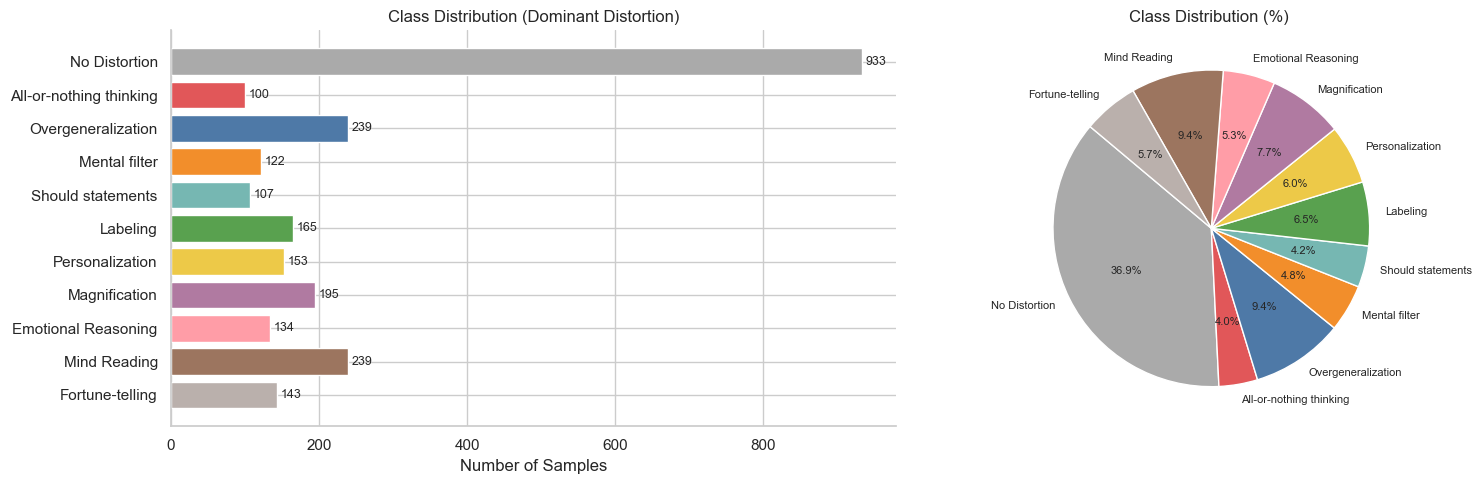

In [7]:
label_counts   = ann_df['Dominant Distortion'].value_counts().reindex(DISTORTION_LABELS)
label_percent  = (label_counts / label_counts.sum() * 100).round(2)

class_balance = pd.DataFrame({'Count': label_counts, 'Percentage (%)': label_percent})
display(class_balance)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = [PALETTE[l] for l in label_counts.index]
ax = axes[0]
bars = ax.barh(label_counts.index[::-1], label_counts.values[::-1], color=colors[::-1])
for bar, val in zip(bars, label_counts.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{val}', va='center', fontsize=9)
ax.set_title('Class Distribution (Dominant Distortion)')
ax.set_xlabel('Number of Samples')

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=label_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 8}
)
axes[1].set_title('Class Distribution (%) ')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

**`No Distortion`** represents the single largest class (36.9%), while distortion classes range from ~4% (`All-or-nothing thinking`) to ~9.4% (`Mind Reading`). This imbalance means class-weighted cross-entropy loss is necessary during training to avoid the model biasing toward the majority class.


## 6. Secondary Distortion Coverage

416 of 2,530 samples have a secondary distortion label, reflecting the subjective and overlapping nature of cognitive distortions. This section shows which pairs co-occur most often.


In [8]:
secondary_counts = ann_df['Secondary Distortion (Optional)'].value_counts()
print(f'Samples with secondary distortion: {ann_df["Secondary Distortion (Optional)"].notna().sum()}')
print(f'Samples without secondary distortion: {ann_df["Secondary Distortion (Optional)"].isna().sum()}')

display(secondary_counts.to_frame('count'))

Samples with secondary distortion: 416
Samples without secondary distortion: 2114


,count
Secondary Distortion (Optional),
Fortune-telling,67
Mind Reading,56
Magnification,50
Personalization,49
Overgeneralization,38
Labeling,38
Emotional Reasoning,35
Mental filter,29
Should statements,28


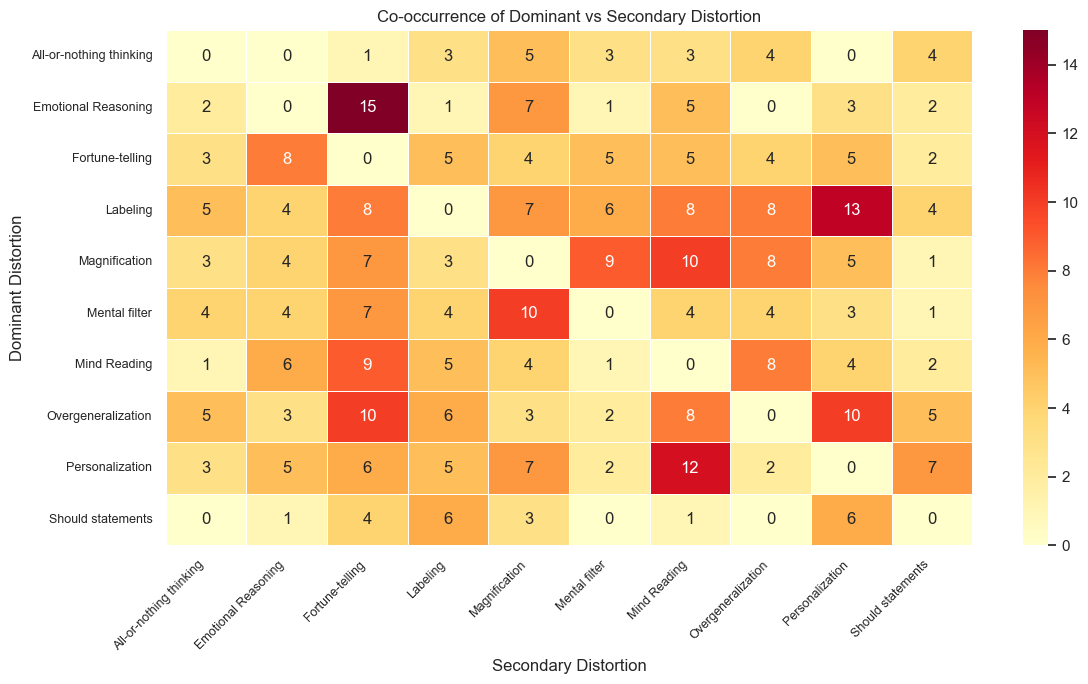

In [9]:
# Co-occurrence heatmap: Dominant vs Secondary
co_occur = (
    ann_df[ann_df['Secondary Distortion (Optional)'].notna()]
    .groupby(['Dominant Distortion', 'Secondary Distortion (Optional)'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 7))
sns.heatmap(
    co_occur,
    annot=True, fmt='d',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title('Co-occurrence of Dominant vs Secondary Distortion')
plt.xlabel('Secondary Distortion')
plt.ylabel('Dominant Distortion')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/distortion_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Distorted Span Coverage

The `Distorted part` column contains the annotated sentence(s) that indicate distorted thinking. This section examines how much of the patient question is typically distorted.


In [10]:
distorted_df = ann_df[ann_df['Distorted part'].notna()].copy()
distorted_df['span_length']   = distorted_df['Distorted part'].str.len()
distorted_df['span_words']    = distorted_df['Distorted part'].str.split().apply(len)
distorted_df['span_coverage'] = (distorted_df['span_length'] / distorted_df['text_length']).clip(upper=1.0)

span_summary = (
    distorted_df.groupby('Dominant Distortion')[['span_words', 'span_coverage']]
    .mean()
    .round(3)
    .reindex([l for l in DISTORTION_LABELS if l != 'No Distortion'])
)
display(span_summary)

,span_words,span_coverage
Dominant Distortion,,
All-or-nothing thinking,43.930,0.346
Overgeneralization,31.008,0.259
Mental filter,42.197,0.286
Should statements,34.243,0.229
Labeling,36.491,0.252
Personalization,38.667,0.259
Magnification,41.169,0.296
Emotional Reasoning,35.687,0.270
Mind Reading,33.527,0.204


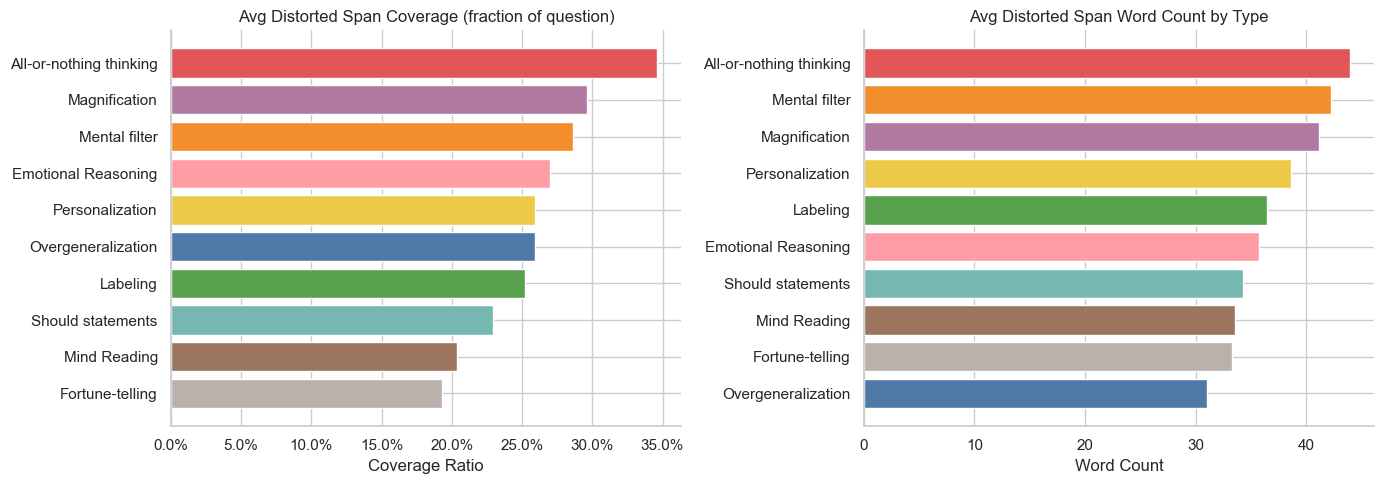

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

distortion_order = span_summary['span_coverage'].sort_values(ascending=True).index.tolist()
colors = [PALETTE[l] for l in distortion_order]

axes[0].barh(distortion_order, span_summary.loc[distortion_order, 'span_coverage'], color=colors)
axes[0].set_title('Avg Distorted Span Coverage (fraction of question)')
axes[0].set_xlabel('Coverage Ratio')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

word_order = span_summary['span_words'].sort_values(ascending=True).index.tolist()
colors2 = [PALETTE[l] for l in word_order]
axes[1].barh(word_order, span_summary.loc[word_order, 'span_words'], color=colors2)
axes[1].set_title('Avg Distorted Span Word Count by Type')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/distorted_span_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Text Length and Writing Style

This section compares writing features across distortion categories. Differences in length, sentence complexity, and punctuation can signal different cognitive styles.


In [12]:
length_features = ['text_length', 'word_count', 'avg_word_len', 'sentence_count', 'unique_words', 'lexical_diversity']

length_summary = (
    ann_df.groupby('Dominant Distortion')[length_features]
    .agg(['mean', 'median', 'std'])
    .round(2)
)
display(length_summary)

text_length                 word_count                 \
                               mean  median     std       mean median     std   
Dominant Distortion                                                             
All-or-nothing thinking      908.29   634.5  723.80     175.21  123.5  139.09   
Emotional Reasoning          908.44   723.5  559.33     174.10  138.5  107.28   
Fortune-telling             1122.69  1015.0  592.47     217.37  188.0  114.23   
Labeling                     970.04   861.0  576.34     186.20  166.0  110.42   
Magnification                947.29   764.0  609.10     182.74  144.0  118.97   
Mental filter               1030.37   821.0  712.68     198.84  160.5  136.53   
Mind Reading                1098.74   963.0  672.58     212.39  184.0  130.05   
No Distortion                658.14   512.0  434.31     126.17   98.0   83.77   
Overgeneralization           852.43   635.0  560.52     162.84  123.0  106.29   
Personalization             1110.56   955.0  713.03     215.06  188.0  137.26   
Should statements            997.47   867.0  633.12     192.86  162.0  124.47   

                        avg_word_len              sentence_count               \
                                mean median   std           mean median   std   
Dominant Distortion                                                             
All-or-nothing thinking         4.19   4.19  0.30          10.11    7.0  8.32   
Emotional Reasoning             4.23   4.18  0.26          10.37    8.0  6.82   
Fortune-telling                 4.18   4.13  0.28          13.01   12.0  8.05   
Labeling                        4.24   4.21  0.30          11.27    9.0  7.31   
Magnification                   4.22   4.23  0.27          10.45    9.0  7.09   
Mental filter                   4.20   4.18  0.26          11.59    9.0  9.25   
Mind Reading                    4.18   4.13  0.28          11.66   10.0  7.82   
No Distortion                   4.26   4.22  0.35           7.58    6.0  4.98   
Overgeneralization              4.26   4.24  0.33           9.76    7.0  7.25   
Personalization                 4.17   4.16  0.29          12.26   11.0  8.39   
Should statements               4.21   4.16  0.30          11.07    9.0  9.20   

                        unique_words               lexical_diversity         \
                                mean median    std              mean median   
Dominant Distortion                                                           
All-or-nothing thinking       106.82   83.0  64.25              0.67   0.68   
Emotional Reasoning           106.07   92.0  50.49              0.66   0.67   
Fortune-telling               127.97  118.0  54.54              0.62   0.62   
Labeling                      113.39  107.0  54.37              0.66   0.64   
Magnification                 110.96   97.0  55.85              0.66   0.66   
Mental filter                 119.39  102.5  62.70              0.65   0.65   
Mind Reading                  124.72  118.0  59.86              0.63   0.62   
No Distortion                  83.48   71.0  42.68              0.71   0.72   
Overgeneralization            101.60   85.0  52.54              0.68   0.69   
Personalization               126.46  116.0  64.40              0.64   0.63   
Should statements             114.72  102.0  58.46              0.64   0.63   

                               
                          std  
Dominant Distortion            
All-or-nothing thinking  0.10  
Emotional Reasoning      0.09  
Fortune-telling          0.08  
Labeling                 0.11  
Magnification            0.10  
Mental filter            0.10  
Mind Reading             0.09  
No Distortion            0.09  
Overgeneralization       0.10  
Personalization          0.10  
Should statements        0.09

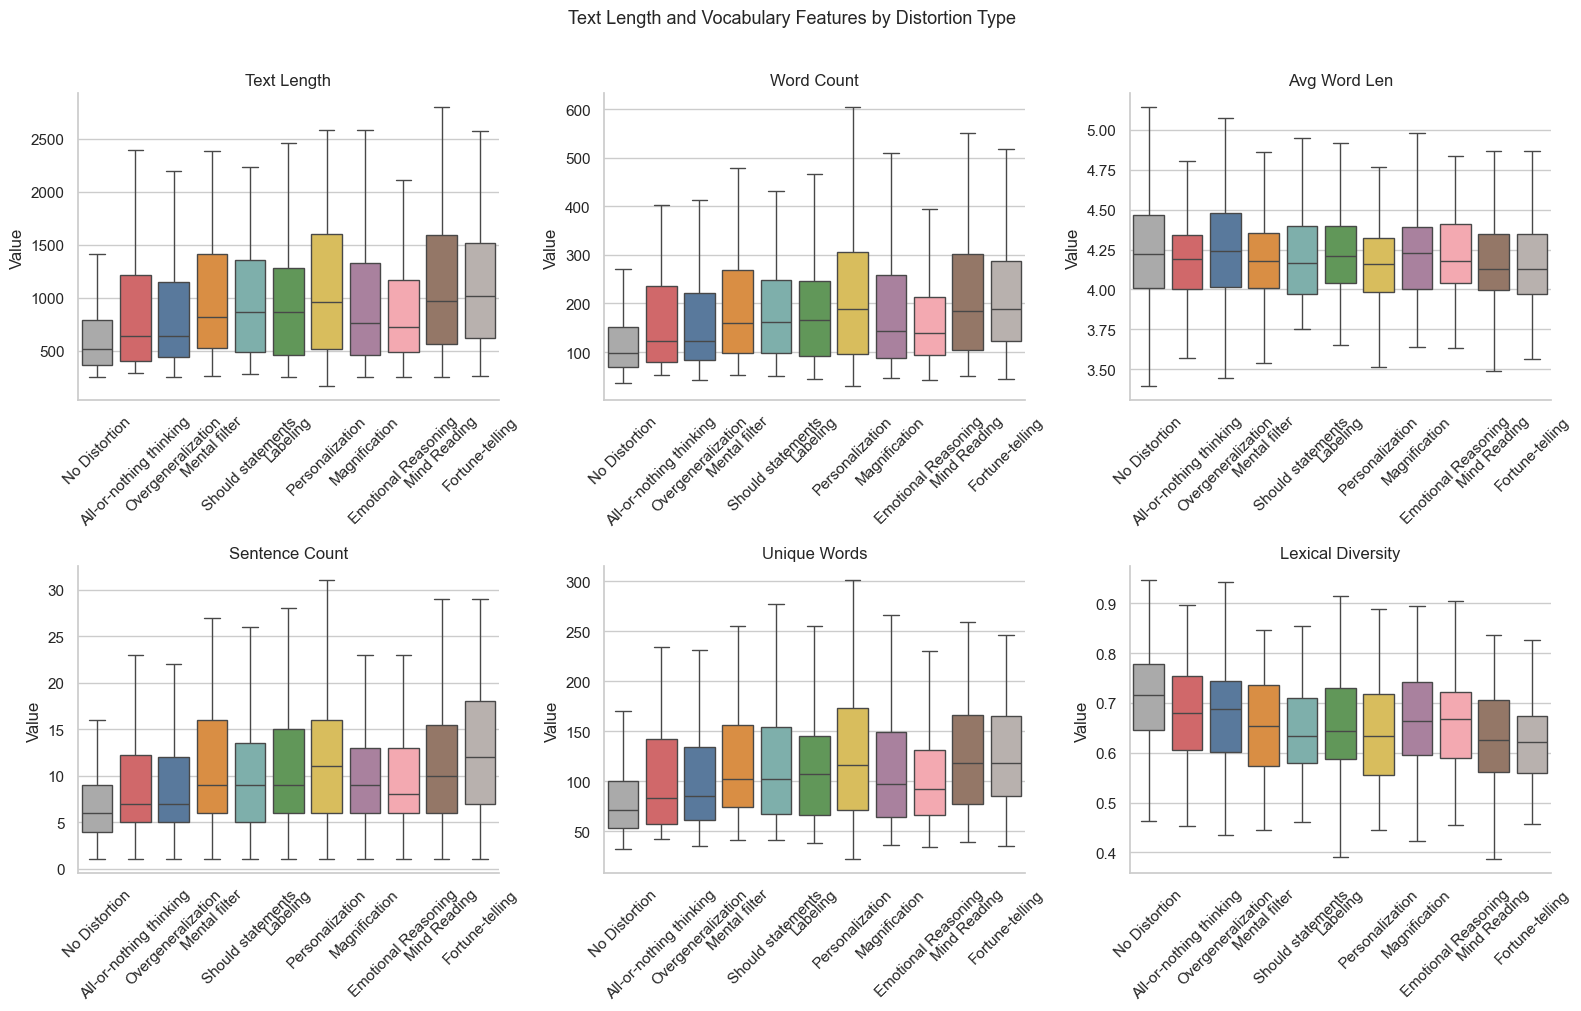

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

order = DISTORTION_LABELS
colors = [PALETTE[l] for l in order]

for ax, col in zip(axes, length_features):
    sns.boxplot(
        data=ann_df,
        x='Dominant Distortion',
        y=col,
        order=order,
        palette=PALETTE,
        showfliers=False,
        ax=ax
    )
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Text Length and Vocabulary Features by Distortion Type', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/text_length_features.png', dpi=150, bbox_inches='tight')
plt.show()

,question_count,exclaim_count,capital_ratio
Dominant Distortion,,,
No Distortion,0.3387,0.0932,0.0232
All-or-nothing thinking,0.3800,0.0700,0.0260
Overgeneralization,0.4854,0.0921,0.0229
Mental filter,0.4508,0.2049,0.0225
Should statements,0.5607,0.2150,0.0233
Labeling,0.5091,0.2848,0.0231
Personalization,0.5425,0.2092,0.0233
Magnification,0.5949,0.2103,0.0242
Emotional Reasoning,0.3731,0.1343,0.0247


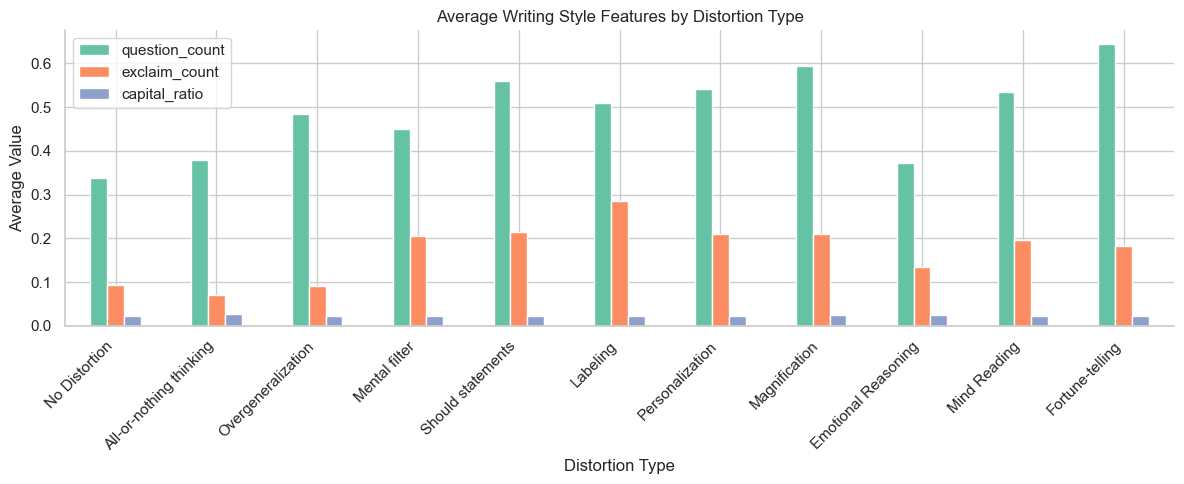

In [14]:
style_features = ['question_count', 'exclaim_count', 'capital_ratio']

style_summary = (
    ann_df.groupby('Dominant Distortion')[style_features]
    .mean()
    .reindex(DISTORTION_LABELS)
    .round(4)
)
display(style_summary)

style_summary.plot(kind='bar', figsize=(12, 5))
plt.title('Average Writing Style Features by Distortion Type')
plt.xlabel('Distortion Type')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/writing_style_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Distortion-Specific Linguistic Features

These lexical features are derived from CBT theory. Each feature is designed to align with particular distortion types, making them useful for both EDA and as auxiliary features during modelling.

- **First-person ratio**: high in Personalization and Labeling (self-referential thinking)
- **Negation count**: high in All-or-nothing thinking and Mental filter (dismissal / filtering)
- **Absolute count**: high in Overgeneralization and All-or-nothing thinking
- **Should count**: expected to peak in Should Statements
- **Future count**: expected to peak in Fortune-telling
- **Mind-read count**: expected to peak in Mind Reading


In [15]:
cbt_features = ['first_person_ratio', 'negation_count', 'absolute_count',
                'should_count', 'future_count', 'mind_read_count']

cbt_summary = (
    ann_df.groupby('Dominant Distortion')[cbt_features]
    .mean()
    .reindex(DISTORTION_LABELS)
    .round(4)
)
display(cbt_summary)

,first_person_ratio,negation_count,absolute_count,should_count,future_count,mind_read_count
Dominant Distortion,,,,,,
No Distortion,0.0924,1.3837,1.4727,0.2176,0.9089,1.1736
All-or-nothing thinking,0.1193,2.2500,2.8800,0.3100,1.5900,2.9600
Overgeneralization,0.1095,2.3808,3.1046,0.2887,1.3766,2.0879
Mental filter,0.1246,2.7705,3.4672,0.4098,1.8852,3.3770
Should statements,0.1191,2.5327,2.7009,0.8131,2.1028,3.3738
Labeling,0.1130,2.2545,2.4667,0.3212,1.5697,3.0364
Personalization,0.1188,2.3791,3.0654,0.5686,1.7843,3.2941
Magnification,0.1174,2.2667,2.5744,0.3231,1.6410,2.4821
Emotional Reasoning,0.1227,2.3433,2.4104,0.3657,1.9776,3.2687


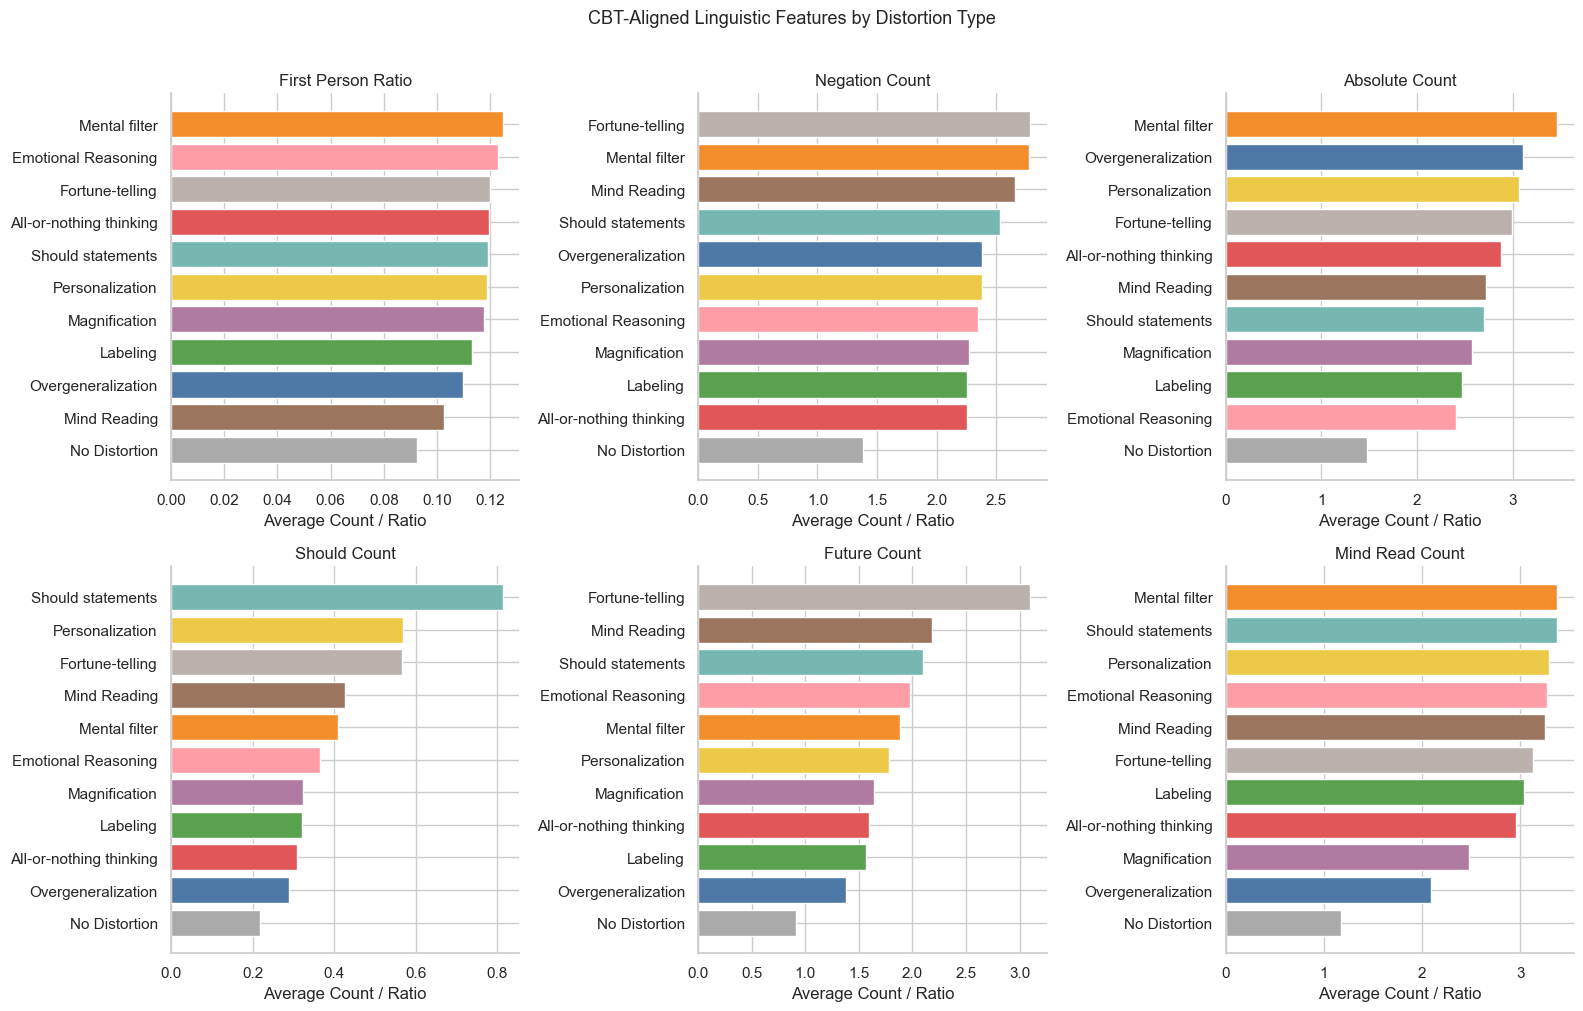

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, cbt_features):
    plot_data = cbt_summary[col].sort_values(ascending=True)
    bar_colors = [PALETTE[l] for l in plot_data.index]
    ax.barh(plot_data.index, plot_data.values, color=bar_colors)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Average Count / Ratio')

plt.suptitle('CBT-Aligned Linguistic Features by Distortion Type', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cbt_linguistic_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Common Words and Bigrams

This section uses simple frequency counts to reveal the most common terms in distorted vs non-distorted text. It is easier to explain than TF-IDF feature importance.


In [17]:
def get_top_terms(df, label_value, text_col='Patient Question', ngram_range=(1,1), top_n=20, min_df=2):
    texts = df.loc[df['Dominant Distortion'] == label_value, text_col].str.lower()
    vectorizer = CountVectorizer(
        stop_words='english',
        ngram_range=ngram_range,
        min_df=min_df,
        token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'
    )
    try:
        matrix = vectorizer.fit_transform(texts)
    except ValueError:
        return pd.DataFrame(columns=['term', 'count'])
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms  = vectorizer.get_feature_names_out()
    return (
        pd.DataFrame({'term': terms, 'count': counts})
        .sort_values('count', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


top_no_dist   = get_top_terms(ann_df, 'No Distortion')
top_distorted = get_top_terms(ann_df, 'Mind Reading')   # Example — change label as needed

print('Top words: No Distortion')
display(top_no_dist)

print('\nTop words: Mind Reading')
display(top_distorted)

Top words: No Distortion


,term,count
0,years,482
1,just,445
2,like,438
3,time,418
4,don,346
5,know,330
6,year,323
7,ve,295
8,old,268
9,want,257



Top words: Mind Reading


,term,count
0,like,271
1,just,243
2,don,239
3,feel,233
4,time,193
5,know,193
6,want,187
7,ve,152
8,people,150
9,really,148


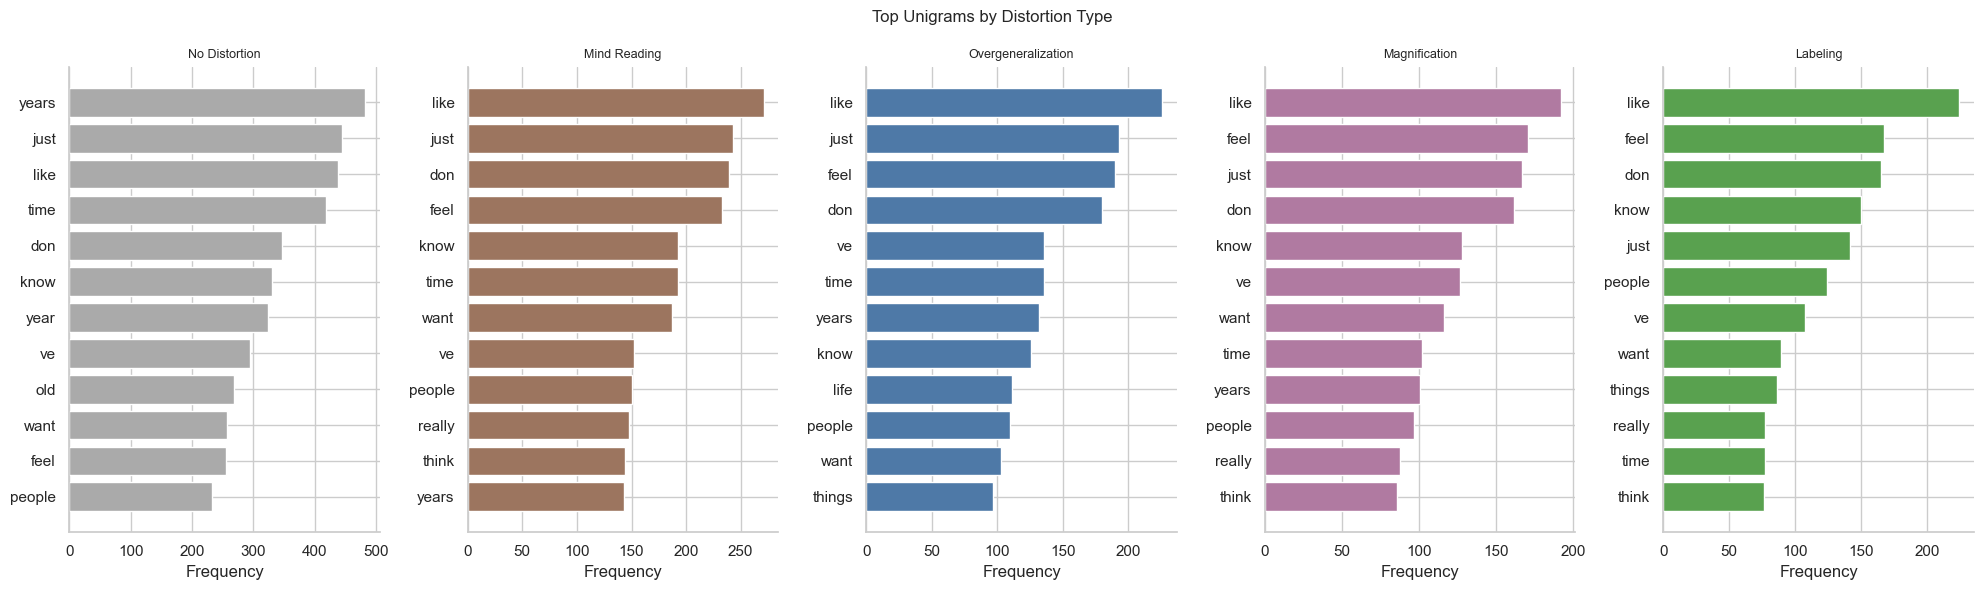

In [18]:
# Compare top words across all 4 high-frequency distortion types
compare_labels = ['No Distortion', 'Mind Reading', 'Overgeneralization', 'Magnification', 'Labeling']

fig, axes = plt.subplots(1, len(compare_labels), figsize=(20, 6), sharey=False)

for ax, label in zip(axes, compare_labels):
    top = get_top_terms(ann_df, label, top_n=12)
    top_sorted = top.sort_values('count', ascending=True)
    ax.barh(top_sorted['term'], top_sorted['count'], color=PALETTE[label])
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Frequency')

plt.suptitle('Top Unigrams by Distortion Type', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/top_words_by_distortion.png', dpi=150, bbox_inches='tight')
plt.show()

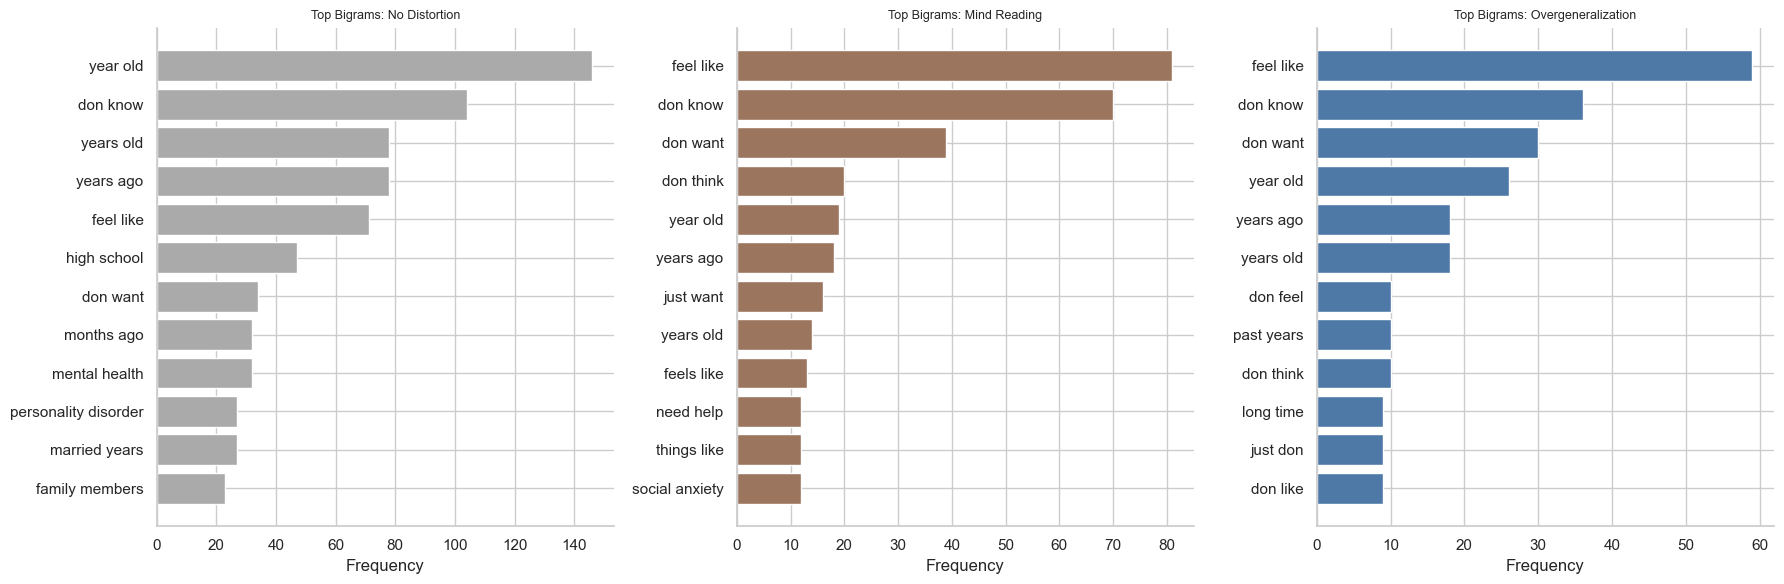

In [19]:
# Bigrams for No Distortion vs top 2 distortions
bigram_labels = ['No Distortion', 'Mind Reading', 'Overgeneralization']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, label in zip(axes, bigram_labels):
    top = get_top_terms(ann_df, label, ngram_range=(2,2), top_n=12)
    top_sorted = top.sort_values('count', ascending=True)
    ax.barh(top_sorted['term'], top_sorted['count'], color=PALETTE[label])
    ax.set_title(f'Top Bigrams: {label}', fontsize=9)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/top_bigrams_by_distortion.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Correlation Analysis

Correlation shows which numeric features are related to the numeric distortion label. This is descriptive, not proof of causation.


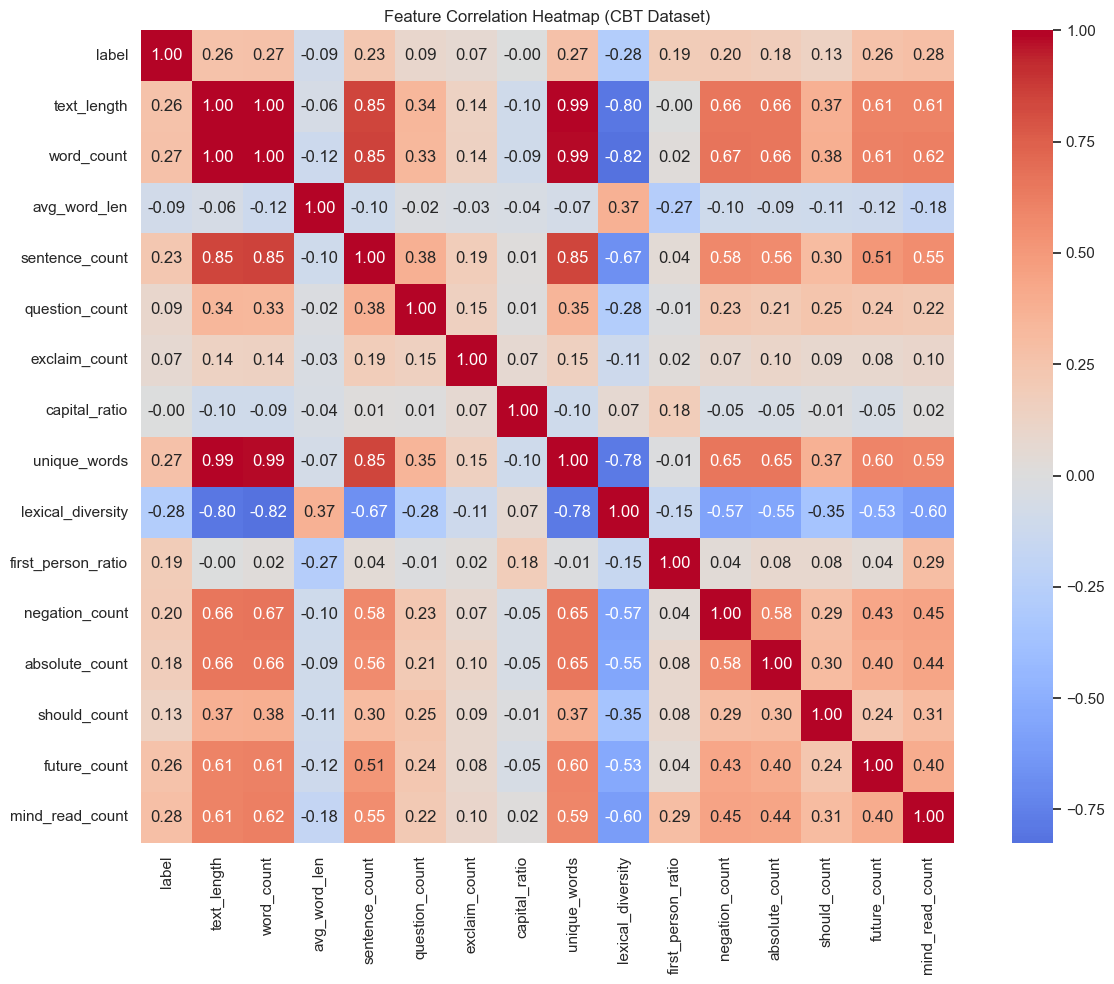

,correlation_with_label
mind_read_count,0.284938
lexical_diversity,-0.279701
unique_words,0.268129
word_count,0.267385
text_length,0.263668
future_count,0.262640
sentence_count,0.225971
negation_count,0.195398
first_person_ratio,0.188662
absolute_count,0.177366


In [20]:
# Encode the label numerically for correlation
ann_df['label'] = ann_df['Dominant Distortion'].map(LABEL_MAP)

correlation_cols = ['label'] + text_features
corr_matrix = ann_df[correlation_cols].corr(numeric_only=True)

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Heatmap (CBT Dataset)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

label_corr = corr_matrix['label'].drop('label').sort_values(key=lambda x: x.abs(), ascending=False)
display(label_corr.to_frame('correlation_with_label'))

## 12. Statistical Tests

Two tests are used here:

1. **Kruskal-Wallis H test**: non-parametric equivalent of ANOVA, checks whether word count differs significantly across distortion categories.
2. **Chi-square test**: checks whether the presence of a secondary distortion label is associated with the dominant distortion type.


In [21]:
# Test 1: Kruskal-Wallis — does word count differ across distortion types?
groups = [
    ann_df.loc[ann_df['Dominant Distortion'] == label, 'word_count'].dropna().values
    for label in DISTORTION_LABELS
]
groups = [g for g in groups if len(g) > 0]

h_stat, kw_p = kruskal(*groups)

print('Kruskal-Wallis H test: word count across distortion types')
print(f'H statistic: {h_stat:.4f}')
print(f'p-value    : {kw_p:.6f}')

if kw_p < 0.05:
    print('Conclusion: Word count differs significantly across distortion types (p < 0.05).')
else:
    print('Conclusion: No significant word count difference across distortion types.')

Kruskal-Wallis H test: word count across distortion types
H statistic: 270.0289
p-value    : 0.000000
Conclusion: Word count differs significantly across distortion types (p < 0.05).


In [22]:
# Test 2: Chi-square — is secondary distortion presence associated with dominant type?
ann_df['has_secondary'] = ann_df['Secondary Distortion (Optional)'].notna().map({True: 'Yes', False: 'No'})

contingency = pd.crosstab(ann_df['Dominant Distortion'], ann_df['has_secondary'])
chi2_stat, chi2_p, chi2_dof, _ = chi2_contingency(contingency)

print('Chi-square test: dominant distortion type vs presence of secondary distortion')
print(f'Chi-square statistic: {chi2_stat:.4f}')
print(f'Degrees of freedom : {chi2_dof}')
print(f'p-value            : {chi2_p:.6f}')

if chi2_p < 0.05:
    print('Conclusion: Distortion type and secondary label presence are significantly associated.')
else:
    print('Conclusion: No significant association found.')

display(contingency)

Chi-square test: dominant distortion type vs presence of secondary distortion
Chi-square statistic: 340.5742
Degrees of freedom : 10
p-value            : 0.000000
Conclusion: Distortion type and secondary label presence are significantly associated.


has_secondary,No,Yes
Dominant Distortion,,
All-or-nothing thinking,77,23
Emotional Reasoning,98,36
Fortune-telling,102,41
Labeling,102,63
Magnification,145,50
Mental filter,81,41
Mind Reading,199,40
No Distortion,933,0
Overgeneralization,187,52


In [23]:
# Test 3: Mann-Whitney U — word count: distorted vs non-distorted
wc_distorted     = ann_df.loc[ann_df['Dominant Distortion'] != 'No Distortion', 'word_count'].dropna()
wc_no_distortion = ann_df.loc[ann_df['Dominant Distortion'] == 'No Distortion', 'word_count'].dropna()

mw_stat, mw_p = mannwhitneyu(wc_distorted, wc_no_distortion, alternative='two-sided')

print('Mann-Whitney U test: word count — distorted vs no distortion')
print(f'Median word count, distorted    : {wc_distorted.median():.2f}')
print(f'Median word count, no distortion: {wc_no_distortion.median():.2f}')
print(f'U statistic                     : {mw_stat:.4f}')
print(f'p-value                         : {mw_p:.6f}')

if mw_p < 0.05:
    print('Conclusion: Word count differs significantly between distorted and non-distorted samples.')
else:
    print('Conclusion: No significant word-count difference found.')

Mann-Whitney U test: word count — distorted vs no distortion
Median word count, distorted    : 159.00
Median word count, no distortion: 98.00
U statistic                     : 1009707.0000
p-value                         : 0.000000
Conclusion: Word count differs significantly between distorted and non-distorted samples.
